## Importing Libraries

In [30]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import cosine_similarity

import pickle

## Loading the Dataset

In [31]:
df = pd.read_csv("online_retail.csv")

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2022-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2022-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom


## Dataset Overview

In [32]:
print("Shape of Dataset:", df.shape)

print("Columns:")
print(df.columns)

print("Dataset Information:")
df.info()

Shape of Dataset: (541909, 8)
Columns:
Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='str')
Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 69.3 MB


## Checking Missing Values and Duplicates

In [33]:
print("Missing Values:")
print(df.isnull().sum())

print("Duplicate Rows:", df.duplicated().sum())

display(df.describe())

Missing Values:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64
Duplicate Rows: 5268


,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


## Data Cleaning

In [34]:
df = df.dropna(subset=["CustomerID"])

print("Remaining missing CustomerID:", df["CustomerID"].isnull().sum())

print("Dataset Shape:", df.shape)

Remaining missing CustomerID: 0
Dataset Shape: (406829, 8)


In [35]:
df = df[~df["InvoiceNo"].astype(str).str.startswith("C")]

print("Dataset Shape:", df.shape)

Dataset Shape: (397924, 8)


In [36]:
df = df[df["Quantity"] > 0]

df = df[df["UnitPrice"] > 0]

print("Dataset Shape:", df.shape)

Dataset Shape: (397884, 8)


## Exploratory Data Analysis

Country
United Kingdom    354321
Germany             9040
France              8341
EIRE                7236
Spain               2484
Netherlands         2359
Belgium             2031
Switzerland         1841
Portugal            1462
Australia           1182
Name: InvoiceNo, dtype: int64

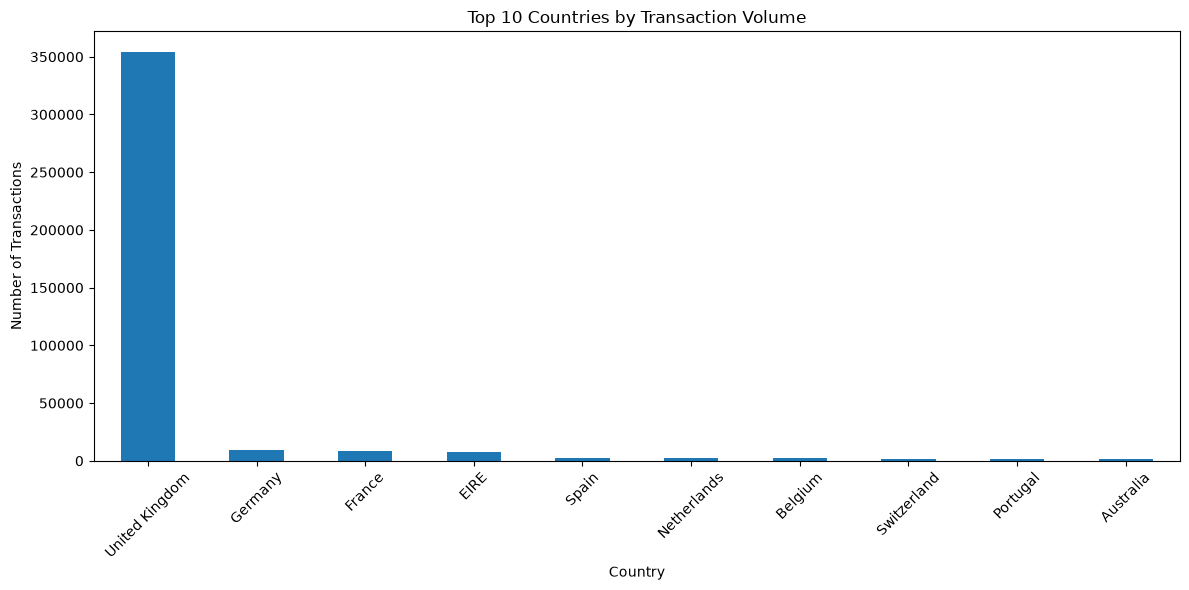

In [37]:
country_transactions = (
    df.groupby("Country")["InvoiceNo"]
      .count()
      .sort_values(ascending=False)
)

display(country_transactions.head(10))

plt.figure(figsize=(12,6))
country_transactions.head(10).plot(kind="bar")

plt.title("Top 10 Countries by Transaction Volume")
plt.xlabel("Country")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

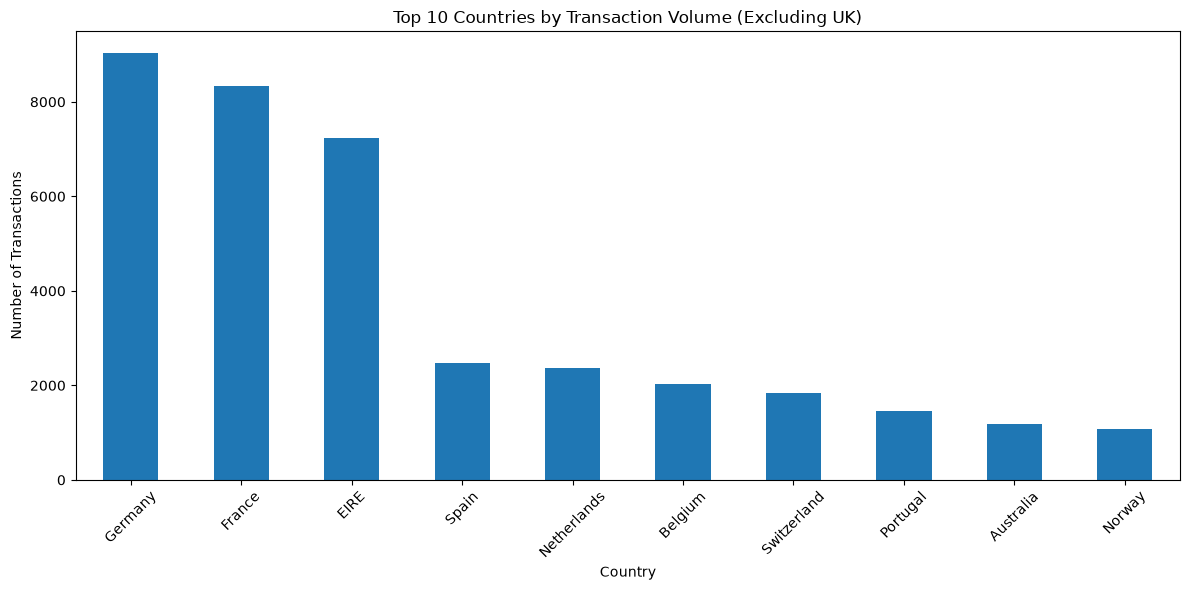

In [38]:
country_transactions = (
    df[df["Country"] != "United Kingdom"]
    .groupby("Country")["InvoiceNo"]
    .count()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))
country_transactions.head(10).plot(kind="bar")

plt.title("Top 10 Countries by Transaction Volume (Excluding UK)")
plt.xlabel("Country")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        77916
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54415
JUMBO BAG RED RETROSPOT               46181
WHITE HANGING HEART T-LIGHT HOLDER    36725
ASSORTED COLOUR BIRD ORNAMENT         35362
PACK OF 72 RETROSPOT CAKE CASES       33693
POPCORN HOLDER                        30931
RABBIT NIGHT LIGHT                    27202
MINI PAINT SET VINTAGE                26076
Name: Quantity, dtype: int64

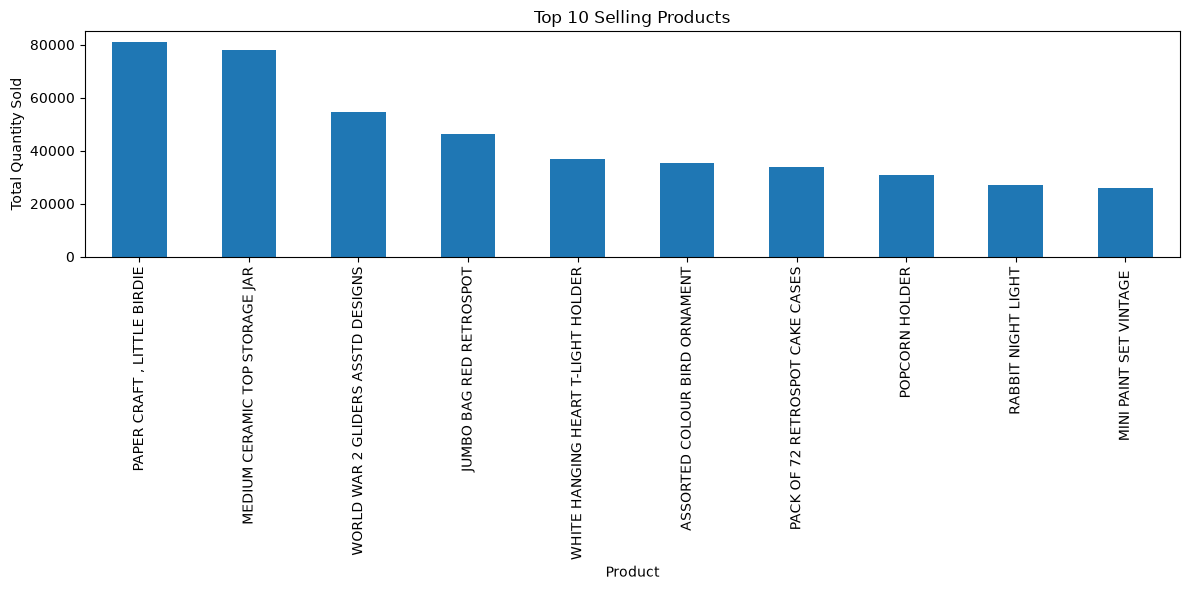

In [39]:
top_products = (
    df.groupby("Description")["Quantity"]
      .sum()
      .sort_values(ascending=False)
)

display(top_products.head(10))

plt.figure(figsize=(12,6))
top_products.head(10).plot(kind="bar")

plt.title("Top 10 Selling Products")
plt.xlabel("Product")
plt.ylabel("Total Quantity Sold")
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

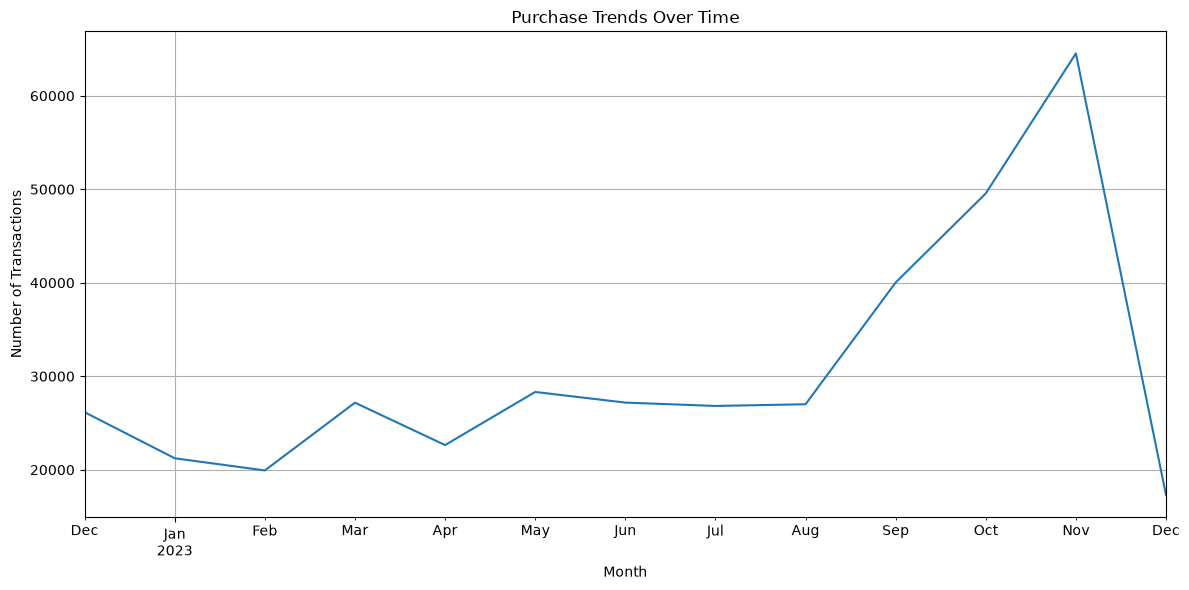

In [40]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

monthly_transactions = (
    df.set_index("InvoiceDate")
      .resample("ME")["InvoiceNo"]
      .count()
)

plt.figure(figsize=(12,6))
monthly_transactions.plot()

plt.title("Purchase Trends Over Time")
plt.xlabel("Month")
plt.ylabel("Number of Transactions")
plt.grid(True)

plt.tight_layout()
plt.show()

In [41]:
df["TotalAmount"] = df["Quantity"] * df["UnitPrice"]

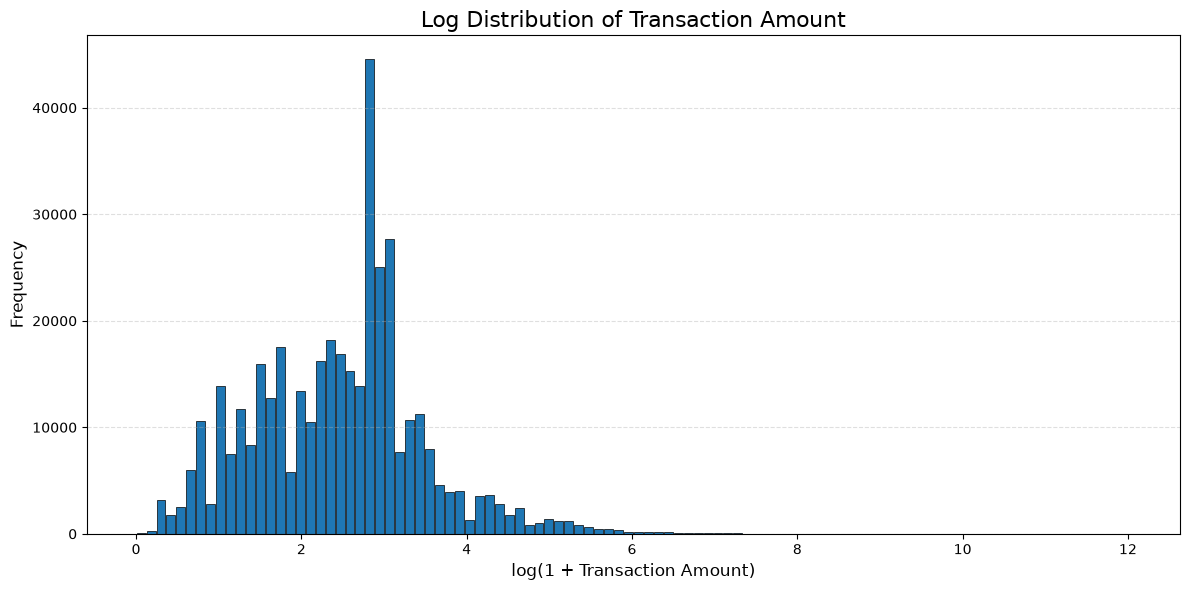

In [42]:
plt.figure(figsize=(12, 6))

plt.hist(
    np.log1p(df["TotalAmount"]),
    bins=100,
    rwidth=0.9,
    edgecolor="black",
    linewidth=0.5
)

plt.title("Log Distribution of Transaction Amount", fontsize=16)
plt.xlabel("log(1 + Transaction Amount)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

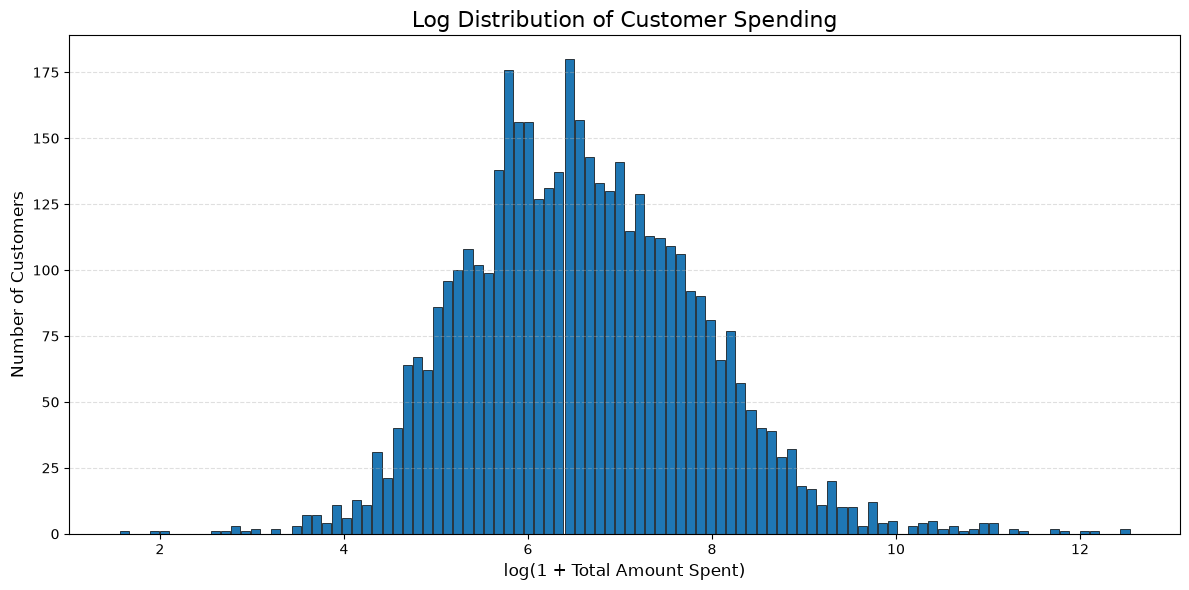

In [43]:
customer_spending = df.groupby("CustomerID")["TotalAmount"].sum()

plt.figure(figsize=(12, 6))

plt.hist(
    np.log1p(customer_spending),
    bins=100,
    rwidth=0.9,
    edgecolor="black",
    linewidth=0.5
)

plt.title("Log Distribution of Customer Spending", fontsize=16)
plt.xlabel("log(1 + Total Amount Spent)", fontsize=12)
plt.ylabel("Number of Customers", fontsize=12)

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

## RFM Analysis

In [44]:
reference_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

rfm = df.groupby("CustomerID").agg({
    "InvoiceDate": lambda x: (reference_date - x.max()).days,
    "InvoiceNo": "nunique",
    "TotalAmount": "sum"
})

rfm.columns = ["Recency", "Frequency", "Monetary"]

rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


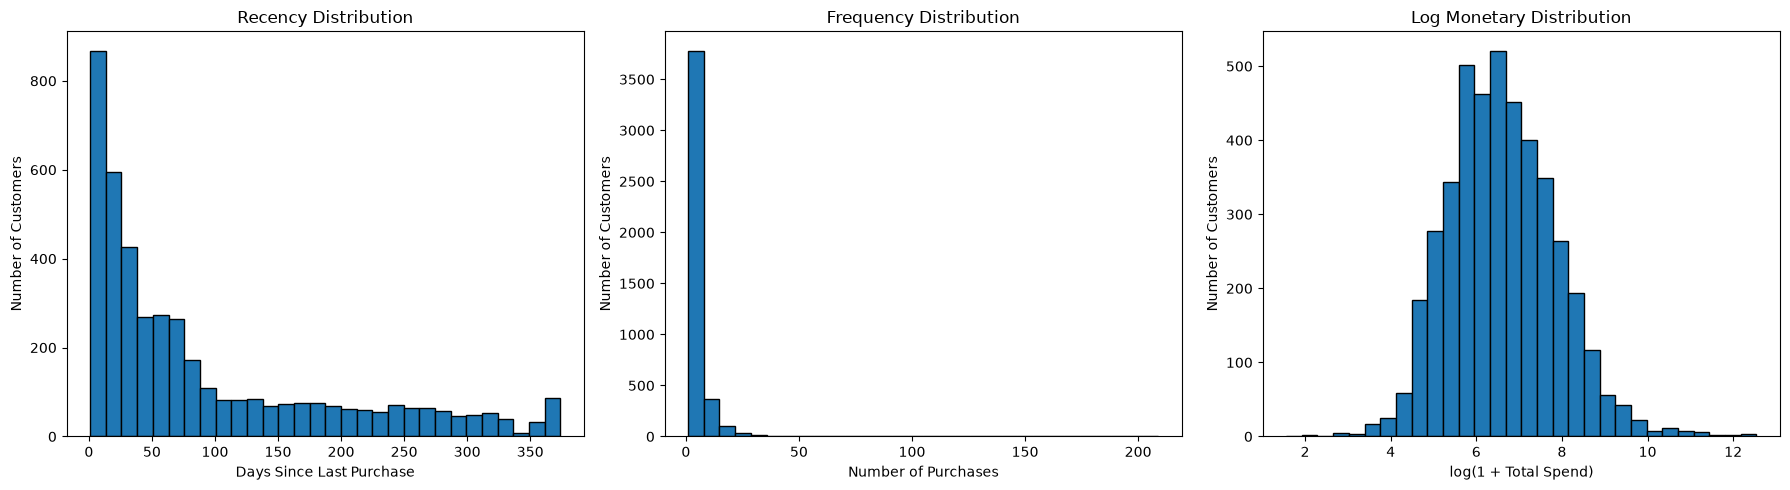

In [45]:
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
plt.hist(rfm["Recency"], bins=30, edgecolor="black")
plt.title("Recency Distribution")
plt.xlabel("Days Since Last Purchase")
plt.ylabel("Number of Customers")

plt.subplot(1, 3, 2)
plt.hist(rfm["Frequency"], bins=30, edgecolor="black")
plt.title("Frequency Distribution")
plt.xlabel("Number of Purchases")
plt.ylabel("Number of Customers")

plt.subplot(1, 3, 3)
plt.hist(np.log1p(rfm["Monetary"]), bins=30, edgecolor="black")
plt.title("Log Monetary Distribution")
plt.xlabel("log(1 + Total Spend)")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

## Feature Scaling

In [46]:
scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm)

rfm_scaled = pd.DataFrame(
    rfm_scaled,
    columns=["Recency", "Frequency", "Monetary"],
    index=rfm.index
)

rfm_scaled.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,2.334574,-0.425097,8.358668
12347.0,-0.905340,0.354417,0.250966
12348.0,-0.175360,-0.035340,-0.028596
12349.0,-0.735345,-0.425097,-0.033012
12350.0,2.174578,-0.425097,-0.191347


## Finding Optimal Number of Clusters

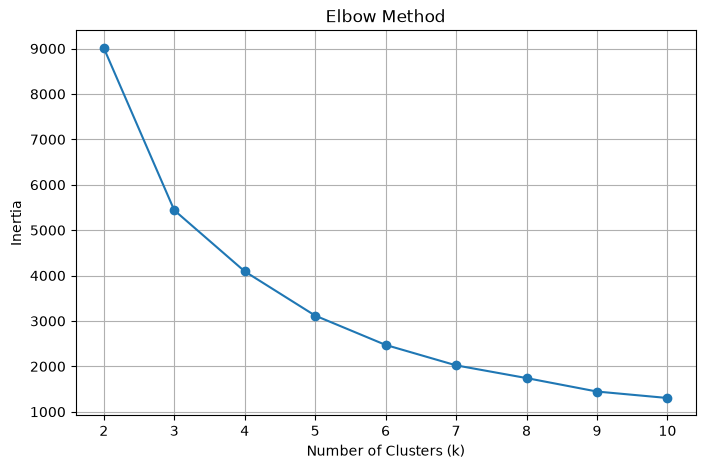

In [47]:
inertia = []

K = range(2, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K, inertia, marker='o')

plt.title("Elbow Method")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")

plt.grid(True)
plt.show()

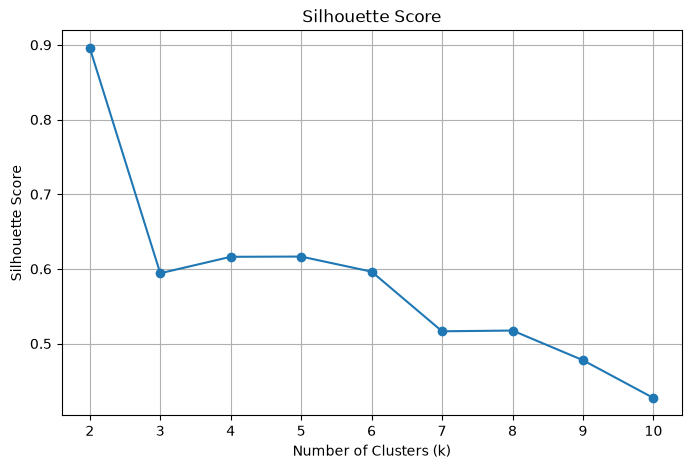

k = 2: 0.8958
k = 3: 0.5942
k = 4: 0.6162
k = 5: 0.6165
k = 6: 0.5963
k = 7: 0.5165
k = 8: 0.5175
k = 9: 0.4777
k = 10: 0.4271


In [48]:
from sklearn.metrics import silhouette_score

silhouette_scores = []

K = range(2, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(rfm_scaled)
    score = silhouette_score(rfm_scaled, labels)
    silhouette_scores.append(score)

plt.figure(figsize=(8,5))
plt.plot(K, silhouette_scores, marker='o')

plt.title("Silhouette Score")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")

plt.grid(True)
plt.show()

for k, score in zip(K, silhouette_scores):
    print(f"k = {k}: {score:.4f}")

## Customer Segmentation

In [49]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)

rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)

rfm.head()

,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12346.0,326,1,77183.60,3
12347.0,2,7,4310.00,0
12348.0,75,4,1797.24,0
12349.0,19,1,1757.55,0
12350.0,310,1,334.40,1


In [50]:
cluster_profile = rfm.groupby("Cluster")[["Recency", "Frequency", "Monetary"]].mean().round(2)

display(cluster_profile)

,Recency,Frequency,Monetary
Cluster,,,
0,43.70,3.68,1359.05
1,248.08,1.55,480.62
2,7.38,82.54,127338.31
3,15.50,22.33,12709.09


In [51]:
cluster_labels = {
    0: "Occasional",
    1: "At-Risk",
    2: "High-Value",
    3: "Regular"
}

rfm["Segment"] = rfm["Cluster"].map(cluster_labels)

rfm.head()

,Recency,Frequency,Monetary,Cluster,Segment
CustomerID,,,,,
12346.0,326,1,77183.60,3,Regular
12347.0,2,7,4310.00,0,Occasional
12348.0,75,4,1797.24,0,Occasional
12349.0,19,1,1757.55,0,Occasional
12350.0,310,1,334.40,1,At-Risk


In [52]:
final_inertia = kmeans.inertia_
final_silhouette = silhouette_score(rfm_scaled, rfm["Cluster"])

print(f"Final Model (k=4) Inertia: {final_inertia:.2f}")
print(f"Final Model (k=4) Silhouette Score: {final_silhouette:.4f}")

Final Model (k=4) Inertia: 4092.14
Final Model (k=4) Silhouette Score: 0.6162


## Cluster Visualization

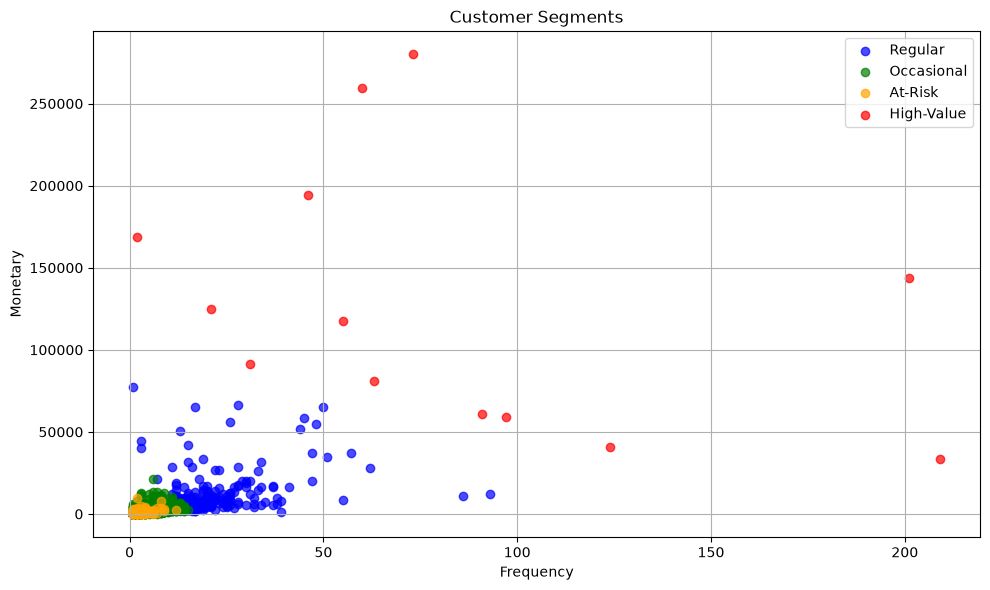

In [53]:
plt.figure(figsize=(10, 6))

colors = {
    "High-Value": "red",
    "Regular": "blue",
    "Occasional": "green",
    "At-Risk": "orange"
}

for segment in rfm["Segment"].unique():
    subset = rfm[rfm["Segment"] == segment]

    plt.scatter(
        subset["Frequency"],
        subset["Monetary"],
        label=segment,
        color=colors[segment],
        alpha=0.7
    )

plt.title("Customer Segments")
plt.xlabel("Frequency")
plt.ylabel("Monetary")

plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## Product Recommendation System

In [54]:
customer_product = df.pivot_table(
    index="CustomerID",
    columns="Description",
    values="Quantity",
    aggfunc="sum",
    fill_value=0
)

print("Customer-Product matrix shape:", customer_product.shape)
customer_product.head()

Customer-Product matrix shape: (4338, 3877)


Description,4 PURPLE FLOCK DINNER CANDLES,50'S CHRISTMAS GIFT BAG LARGE,DOLLY GIRL BEAKER,I LOVE LONDON MINI BACKPACK,I LOVE LONDON MINI RUCKSACK,NINE DRAWER OFFICE TIDY,OVAL WALL MIRROR DIAMANTE,RED SPOT GIFT BAG LARGE,SET 2 TEA TOWELS I LOVE LONDON,SPACEBOY BABY GIFT SET,...,ZINC STAR T-LIGHT HOLDER,ZINC SWEETHEART SOAP DISH,ZINC SWEETHEART WIRE LETTER RACK,ZINC T-LIGHT HOLDER STAR LARGE,ZINC T-LIGHT HOLDER STARS LARGE,ZINC T-LIGHT HOLDER STARS SMALL,ZINC TOP 2 DOOR WOODEN SHELF,ZINC WILLIE WINKIE CANDLE STICK,ZINC WIRE KITCHEN ORGANISER,ZINC WIRE SWEETHEART LETTER TRAY
CustomerID,,,,,,,,,,,,,,,,,,,,,
12346.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12347.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12348.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12349.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12350.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [55]:
product_similarity = cosine_similarity(customer_product.T)

product_similarity_df = pd.DataFrame(
    product_similarity,
    index=customer_product.columns,
    columns=customer_product.columns
)

print("Product similarity matrix shape:", product_similarity_df.shape)
product_similarity_df.head()

Product similarity matrix shape: (3877, 3877)


Description,4 PURPLE FLOCK DINNER CANDLES,50'S CHRISTMAS GIFT BAG LARGE,DOLLY GIRL BEAKER,I LOVE LONDON MINI BACKPACK,I LOVE LONDON MINI RUCKSACK,NINE DRAWER OFFICE TIDY,OVAL WALL MIRROR DIAMANTE,RED SPOT GIFT BAG LARGE,SET 2 TEA TOWELS I LOVE LONDON,SPACEBOY BABY GIFT SET,...,ZINC STAR T-LIGHT HOLDER,ZINC SWEETHEART SOAP DISH,ZINC SWEETHEART WIRE LETTER RACK,ZINC T-LIGHT HOLDER STAR LARGE,ZINC T-LIGHT HOLDER STARS LARGE,ZINC T-LIGHT HOLDER STARS SMALL,ZINC TOP 2 DOOR WOODEN SHELF,ZINC WILLIE WINKIE CANDLE STICK,ZINC WIRE KITCHEN ORGANISER,ZINC WIRE SWEETHEART LETTER TRAY
Description,,,,,,,,,,,,,,,,,,,,,
4 PURPLE FLOCK DINNER CANDLES,1.000000,0.000000,0.000021,0.000227,0.000000,0.000000,0.020155,0.000000,0.000262,0.063396,...,0.0,0.001368,0.015886,0.001767,0.0,0.002846,0.0,0.013128,0.000000,0.002594
50'S CHRISTMAS GIFT BAG LARGE,0.000000,1.000000,0.003533,0.004001,0.000000,0.020034,0.027433,0.900849,0.119031,0.013380,...,0.0,0.001718,0.015572,0.018032,0.0,0.015710,0.0,0.011238,0.000000,0.029793
DOLLY GIRL BEAKER,0.000021,0.003533,1.000000,0.870851,0.980561,0.006296,0.005302,0.003034,0.001765,0.411331,...,0.0,0.000043,0.002869,0.344923,0.0,0.525860,0.0,0.822946,0.000097,0.006665
I LOVE LONDON MINI BACKPACK,0.000227,0.004001,0.870851,1.000000,0.883883,0.019879,0.004904,0.004043,0.008270,0.382056,...,0.0,0.001409,0.004197,0.310017,0.0,0.471717,0.0,0.749210,0.000000,0.010393
I LOVE LONDON MINI RUCKSACK,0.000000,0.000000,0.980561,0.883883,1.000000,0.000000,0.000000,0.000000,0.000000,0.410578,...,0.0,0.000000,0.000000,0.347021,0.0,0.530836,0.0,0.837170,0.000000,0.000000


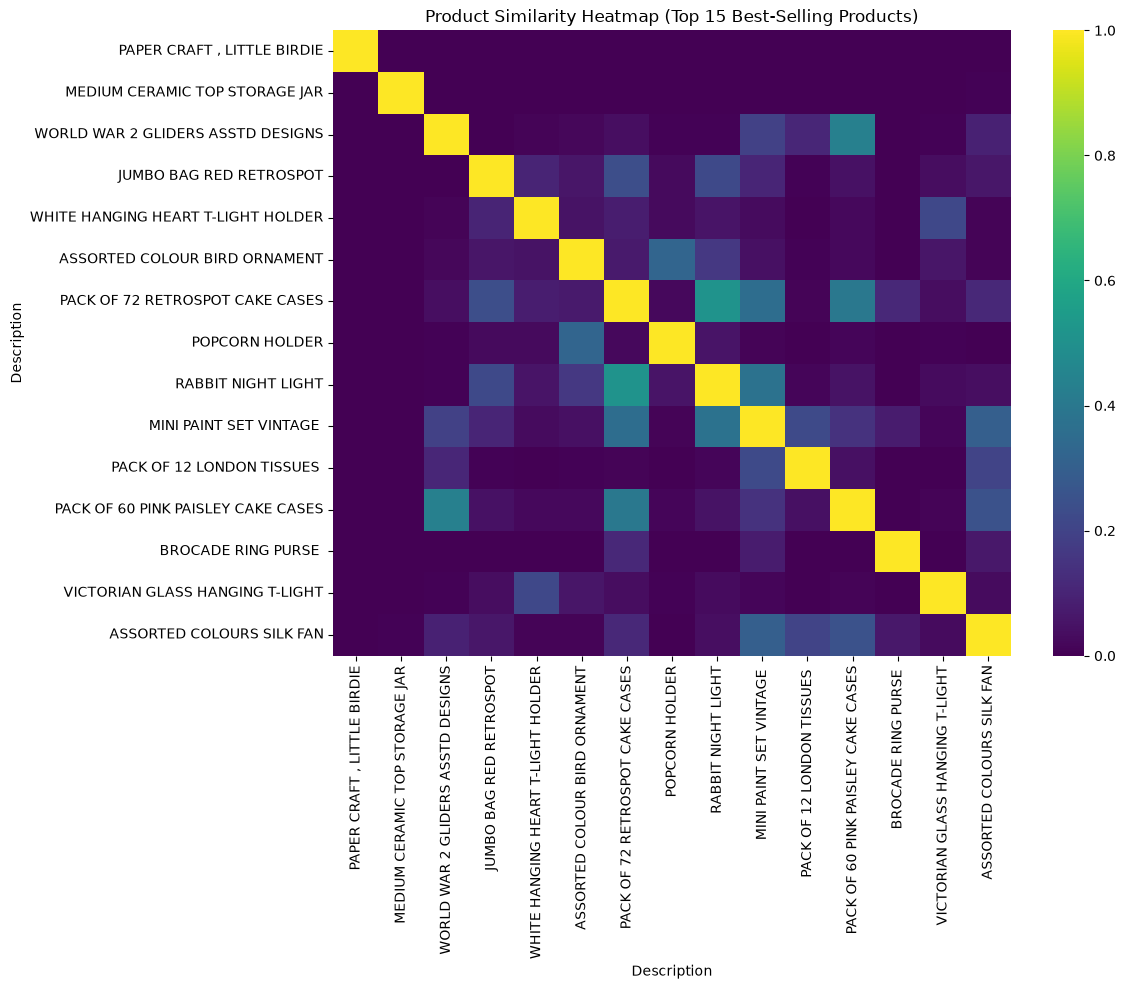

In [56]:
top_15_products = top_products.head(15).index

plt.figure(figsize=(12, 10))
sns.heatmap(
    product_similarity_df.loc[top_15_products, top_15_products],
    annot=False,
    cmap="viridis"
)

plt.title("Product Similarity Heatmap (Top 15 Best-Selling Products)")
plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [57]:
def get_similar_products(product_name, similarity_df, top_n=5):
    if product_name not in similarity_df.columns:
        print(f"'{product_name}' not found in the product catalog.")
        return None

    scores = similarity_df[product_name].drop(labels=[product_name])
    return scores.sort_values(ascending=False).head(top_n)


sample_product = top_products.index[0]
print(f"Products similar to '{sample_product}':\n")
print(get_similar_products(sample_product, product_similarity_df, top_n=5))

Products similar to 'PAPER CRAFT , LITTLE BIRDIE':

Description
PANTRY PASTRY BRUSH                  0.007219
PANTRY SCRUBBING BRUSH               0.002786
 4 PURPLE FLOCK DINNER CANDLES       0.000000
 50'S CHRISTMAS GIFT BAG LARGE       0.000000
ZINC HEART LATTICE T-LIGHT HOLDER    0.000000
Name: PAPER CRAFT , LITTLE BIRDIE, dtype: float64


In [58]:
import pickle

with open("kmeans_model.pkl", "wb") as file:
    pickle.dump(kmeans, file)

with open("scaler.pkl", "wb") as file:
    pickle.dump(scaler, file)

with open("product_similarity.pkl", "wb") as file:
    pickle.dump(product_similarity_df, file)

print("Models saved successfully!")

Models saved successfully!
